In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Find the Flag
**Objective:** Use a decision tree to determine what continent a flag is from.

## Investigate the Data

In [3]:
# 1. Load the flag dataset.
flags = pd.read_csv('flags.csv', header=0)

In [4]:
# 2a. Have a look at the variable names.
print('Variables:', flags.columns)

Variables: Index(['Name', 'Landmass', 'Zone', 'Area', 'Population', 'Language',
       'Religion', 'Bars', 'Stripes', 'Colors', 'Red', 'Green', 'Blue', 'Gold',
       'White', 'Black', 'Orange', 'Mainhue', 'Circles', 'Crosses', 'Saltires',
       'Quarters', 'Sunstars', 'Crescent', 'Triangle', 'Icon', 'Animate',
       'Text', 'Topleft', 'Botright'],
      dtype='str')


In [5]:
# 2b. Have a look at the first few rows.
print('A preview of the flags dataset:')
print(flags.head())

A preview of the flags dataset:
             Name  Landmass  Zone  Area  Population  Language  Religion  Bars  \
0     Afghanistan         5     1   648          16        10         2     0   
1         Albania         3     1    29           3         6         6     0   
2         Algeria         4     1  2388          20         8         2     2   
3  American-Samoa         6     3     0           0         1         1     0   
4         Andorra         3     1     0           0         6         0     3   

   Stripes  Colors  ...  Saltires  Quarters  Sunstars  Crescent  Triangle  \
0        3       5  ...         0         0         1         0         0   
1        0       3  ...         0         0         1         0         0   
2        0       3  ...         0         0         1         1         0   
3        0       5  ...         0         0         0         0         1   
4        0       3  ...         0         0         0         0         0   

   Icon  Animate T

### Task 3

**Question:** In the case of Algeria, its ```Language``` value is 8. What does that mean?\
**Answer:** According to the *Additional Variable Information* section of the repository, ```8``` in the context of languages means Arabic. Therefore, Algerians speak Arabic.

**Question:** Which landmass is Andorra in?\
**Answer:** According to the preview below, Andorra has a ```Landmass``` value of 3. Since 3 in this context means Europe, Andorra is in Europe.

## Create Your Data and Labels

In [12]:
# 4. Get landmasses from the flag dataset.
labels = flags[['Landmass']]

In [13]:
# 5. Get colours from the flag dataset.
data = flags[['Red', 'Green', 'Blue', 'Gold', 'White', 'Black', 'Orange']]

In [14]:
# 6. Split the two DataFrames above into training and testing sets.
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, random_state=1)

## Make and Test the Model

In [16]:
# 7. Create a DecisionTreeClassifier object.
tree = DecisionTreeClassifier(random_state=1)

In [17]:
# 8. Fit the tree to the training set.
tree.fit(train_data, train_labels)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [20]:
# 9. Produce the tree's accuracy score.
print('Accuracy (%):', tree.score(test_data, test_labels)*100.0)

Accuracy (%): 34.69387755102041


**Question:** Since there are six possible landmasses, if we randomly guessed, we'd expect to be right about 16% of the time. Did our decision tree beat randomly guessing?
**Answer:** Yes, because our model is accurate about 34% of the time, more than our 16%.

## Tune the Model

In [26]:
# 10. Create, train, and test the tree inside a for loop.
scores = [] # for Task 11
for i in range(1, 21):
    tree = DecisionTreeClassifier(max_depth=i)
    tree.fit(train_data, train_labels)
    print(f'Accuracy (%) at max_depth={i}:', tree.score(test_data, test_labels)*100.0)
    scores.append(tree.score(test_data, test_labels))

Accuracy (%) at max_depth=1: 34.69387755102041
Accuracy (%) at max_depth=2: 22.448979591836736
Accuracy (%) at max_depth=3: 34.69387755102041
Accuracy (%) at max_depth=4: 32.6530612244898
Accuracy (%) at max_depth=5: 34.69387755102041
Accuracy (%) at max_depth=6: 34.69387755102041
Accuracy (%) at max_depth=7: 34.69387755102041
Accuracy (%) at max_depth=8: 34.69387755102041
Accuracy (%) at max_depth=9: 34.69387755102041
Accuracy (%) at max_depth=10: 34.69387755102041
Accuracy (%) at max_depth=11: 34.69387755102041
Accuracy (%) at max_depth=12: 34.69387755102041
Accuracy (%) at max_depth=13: 34.69387755102041
Accuracy (%) at max_depth=14: 34.69387755102041
Accuracy (%) at max_depth=15: 34.69387755102041
Accuracy (%) at max_depth=16: 34.69387755102041
Accuracy (%) at max_depth=17: 34.69387755102041
Accuracy (%) at max_depth=18: 34.69387755102041
Accuracy (%) at max_depth=19: 34.69387755102041
Accuracy (%) at max_depth=20: 34.69387755102041


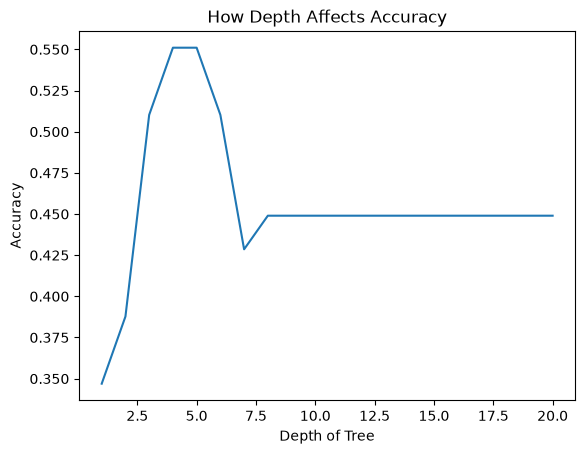

In [35]:
# 12. Plot scores with respect to depth.
plt.plot(range(1, 21), scores)
plt.xlabel('Depth of Tree')
plt.ylabel('Accuracy')
plt.title('How Depth Affects Accuracy')
plt.show()

In [33]:
# 13a. Add more features to improve the tree's performance.
data = flags[[
            'Red', 'Green', 'Blue', 'Gold', 'White', 'Black', 'Orange', # colours
            'Circles', 'Crosses', 'Saltires', 'Quarters', 'Sunstars', 'Crescent', 'Triangle' # shapes
             ]]

Accuracy (%) at max_depth=1: 34.69387755102041
Accuracy (%) at max_depth=2: 38.775510204081634
Accuracy (%) at max_depth=3: 51.02040816326531
Accuracy (%) at max_depth=4: 55.10204081632652
Accuracy (%) at max_depth=5: 55.10204081632652
Accuracy (%) at max_depth=6: 51.02040816326531
Accuracy (%) at max_depth=7: 42.857142857142854
Accuracy (%) at max_depth=8: 44.89795918367347
Accuracy (%) at max_depth=9: 44.89795918367347
Accuracy (%) at max_depth=10: 44.89795918367347
Accuracy (%) at max_depth=11: 44.89795918367347
Accuracy (%) at max_depth=12: 44.89795918367347
Accuracy (%) at max_depth=13: 44.89795918367347
Accuracy (%) at max_depth=14: 44.89795918367347
Accuracy (%) at max_depth=15: 44.89795918367347
Accuracy (%) at max_depth=16: 44.89795918367347
Accuracy (%) at max_depth=17: 44.89795918367347
Accuracy (%) at max_depth=18: 44.89795918367347
Accuracy (%) at max_depth=19: 44.89795918367347
Accuracy (%) at max_depth=20: 44.89795918367347


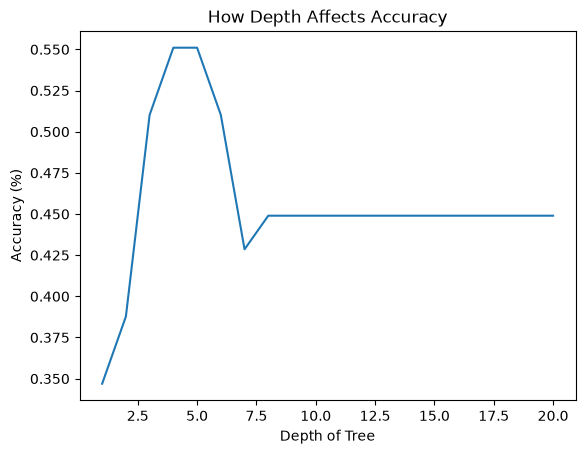

In [34]:
# 13b. Run the decision tree algorithm again.
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, random_state=1)
scores = []
for i in range(1, 21):
    tree = DecisionTreeClassifier(max_depth=i)
    tree.fit(train_data, train_labels)
    print(f'Accuracy (%) at max_depth={i}:', tree.score(test_data, test_labels)*100.0)
    scores.append(tree.score(test_data, test_labels))
plt.plot(range(1, 21), scores)
plt.xlabel('Depth of Tree')
plt.ylabel('Accuracy')
plt.title('How Depth Affects Accuracy')
plt.show()

**Verdict:** The tree is the most accurate when its maximum depth is 4 or 5. Any deeper than that and the tree's accuracy will drop to 